In [100]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns




In [101]:
df = pd.read_csv ('website_books_data.csv')
df.head(10)

,title,price,rating,category
0,It's Only the Himalayas,45.17,2,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,49.43,4,Travel
2,See America: A Celebration of Our National Par...,48.87,3,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,Travel
4,Under the Tuscan Sun,37.33,3,Travel
5,A Summer In Europe,44.34,2,Travel
6,The Great Railway Bazaar,30.54,1,Travel
7,A Year in Provence (Provence #1),56.88,4,Travel
8,The Road to Little Dribbling: Adventures of an...,23.21,1,Travel
9,Neither Here nor There: Travels in Europe,38.95,3,Travel


In [102]:
df.columns

Index(['title', 'price', 'rating', 'category'], dtype='object')

In [103]:

df.info()
df.shape
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   title     1000 non-null   object 
 1   price     1000 non-null   float64
 2   rating    1000 non-null   int64  
 3   category  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


,price,rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


In [104]:
df.isnull().sum()
# df["Price"] = "£" + df["price"].astype(str)
df

,title,price,rating,category
0,It's Only the Himalayas,45.17,2,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,49.43,4,Travel
2,See America: A Celebration of Our National Par...,48.87,3,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,Travel
4,Under the Tuscan Sun,37.33,3,Travel
...,...,...,...,...
995,Why the Right Went Wrong: Conservatism--From G...,52.65,4,Politics
996,Equal Is Unfair: America's Misguided Fight Aga...,56.86,1,Politics
997,Amid the Chaos,36.58,1,Cultural
998,Dark Notes,19.19,5,Erotica


In [105]:
# df.drop(columns= ['Price'],inplace=True)
df

,title,price,rating,category
0,It's Only the Himalayas,45.17,2,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,49.43,4,Travel
2,See America: A Celebration of Our National Par...,48.87,3,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,Travel
4,Under the Tuscan Sun,37.33,3,Travel
...,...,...,...,...
995,Why the Right Went Wrong: Conservatism--From G...,52.65,4,Politics
996,Equal Is Unfair: America's Misguided Fight Aga...,56.86,1,Politics
997,Amid the Chaos,36.58,1,Cultural
998,Dark Notes,19.19,5,Erotica


In [106]:
df["category"] = df["category"].replace("Default", "friction")

<h2>performing eda for better understanding of data</h2>

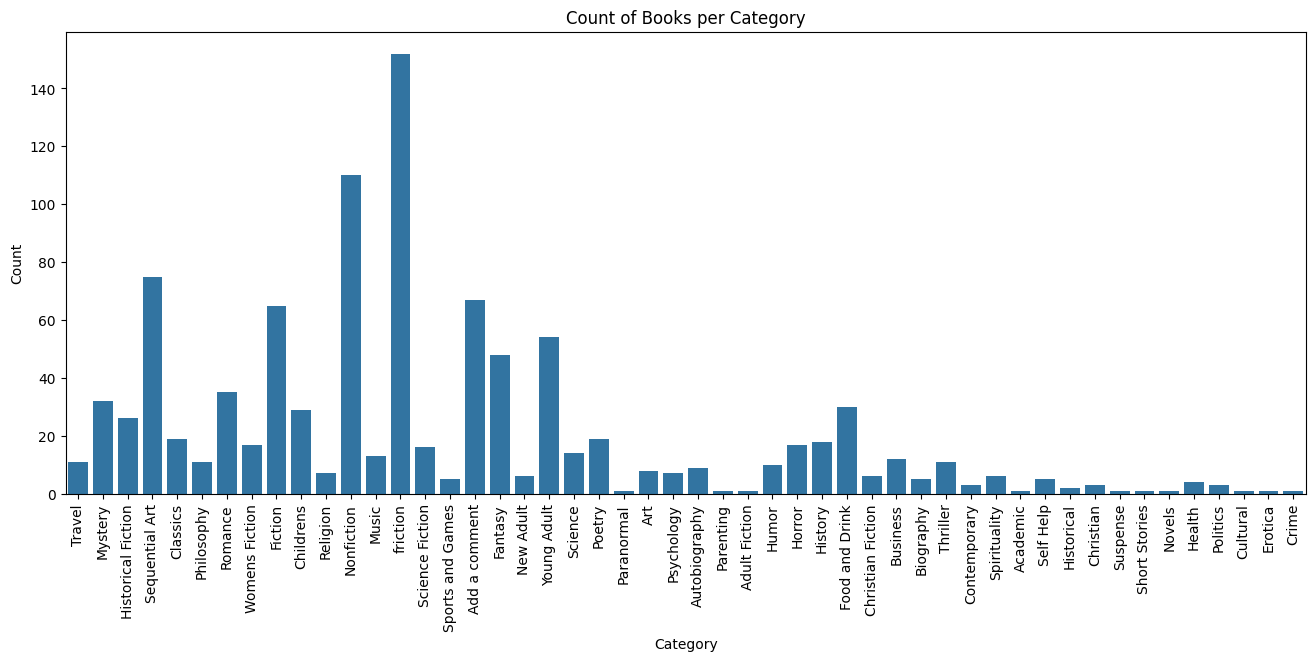

In [107]:

# plt.figure()
plt.figure(figsize=(16,6))
sns.countplot(data=df, x="category")

plt.xticks(rotation=90)
plt.title("Count of Books per Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

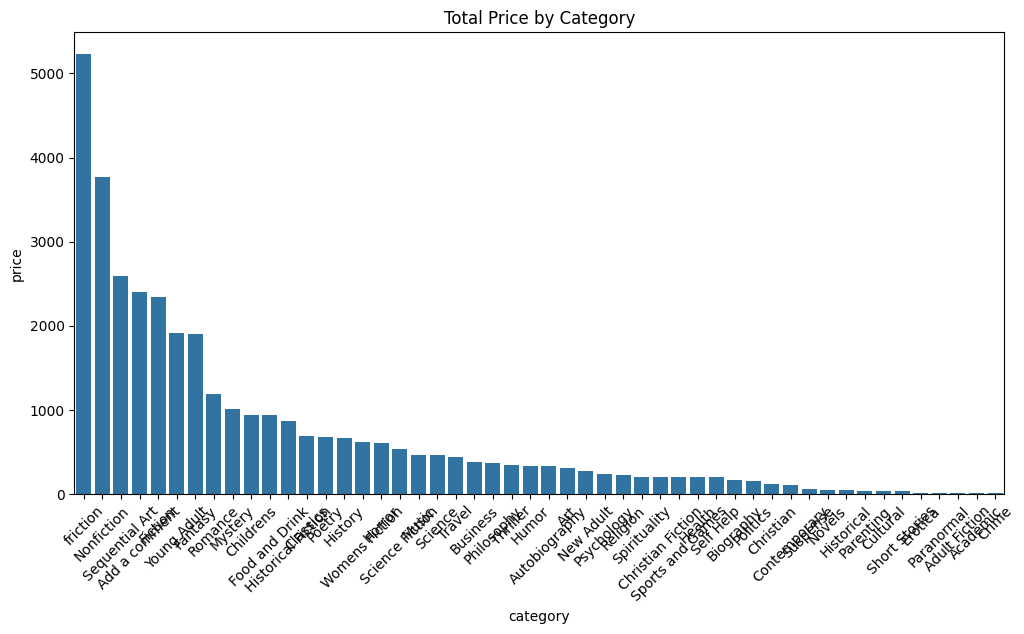

In [108]:
# df['Price'] =df['price'].str.replace('£','')
# df
category_price = df.groupby("category")["price"].sum().sort_values(ascending=False).reset_index()

# print(category_price)


plt.figure(figsize=(12,6))

sns.barplot(data=category_price, x="category", y="price")

plt.xticks(rotation=45)
plt.title("Total Price by Category")

plt.show()

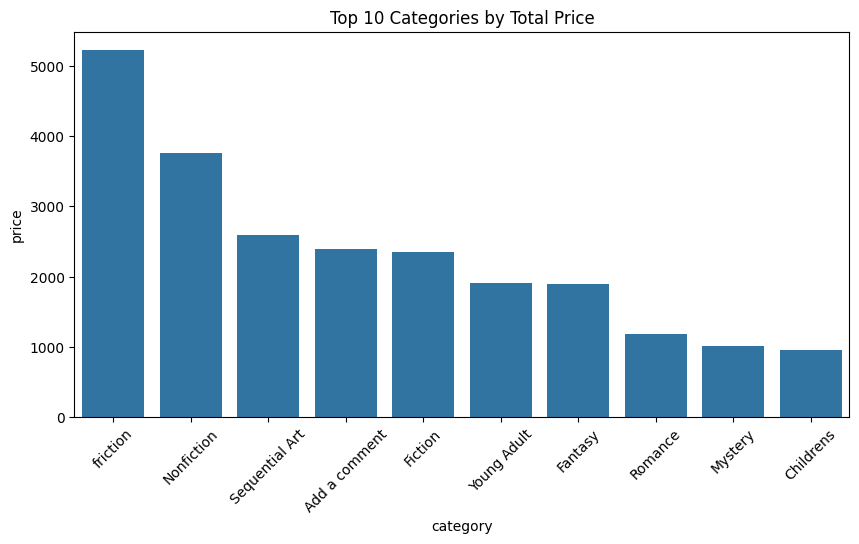

In [109]:
df["price"] = df["price"].astype(float)
category_price = df.groupby("category")["price"].sum() \
                   .sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=category_price, x="category", y="price")

plt.xticks(rotation=45)
plt.title("Top 10 Categories by Total Price")

plt.show()

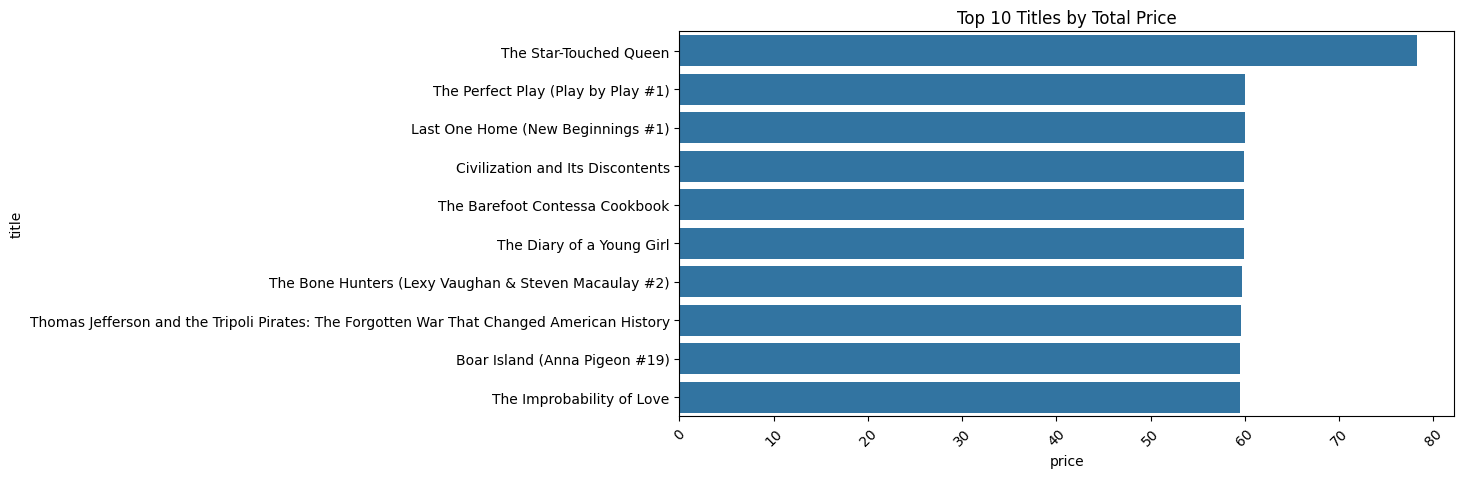

In [110]:

title_price = df.groupby("title")["price"].sum().sort_values(ascending=False).head(10).reset_index()
                   

plt.figure(figsize=(10,5))

sns.barplot(data=title_price, y="title", x="price")

plt.xticks(rotation=45)
plt.title("Top 10 Titles by Total Price")

plt.show()

In [111]:
df

,title,price,rating,category
0,It's Only the Himalayas,45.17,2,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,49.43,4,Travel
2,See America: A Celebration of Our National Par...,48.87,3,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,Travel
4,Under the Tuscan Sun,37.33,3,Travel
...,...,...,...,...
995,Why the Right Went Wrong: Conservatism--From G...,52.65,4,Politics
996,Equal Is Unfair: America's Misguided Fight Aga...,56.86,1,Politics
997,Amid the Chaos,36.58,1,Cultural
998,Dark Notes,19.19,5,Erotica


In [112]:
df["rating"] = df["rating"].astype(int)
category_rating = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(10).reset_index()
          

print(category_rating)

            category    rating
0            Erotica  5.000000
1      Adult Fiction  5.000000
2             Novels  5.000000
3  Christian Fiction  4.166667
4             Health  3.750000
5                Art  3.625000
6             Poetry  3.526316
7              Humor  3.400000
8       Spirituality  3.333333
9        Young Adult  3.296296


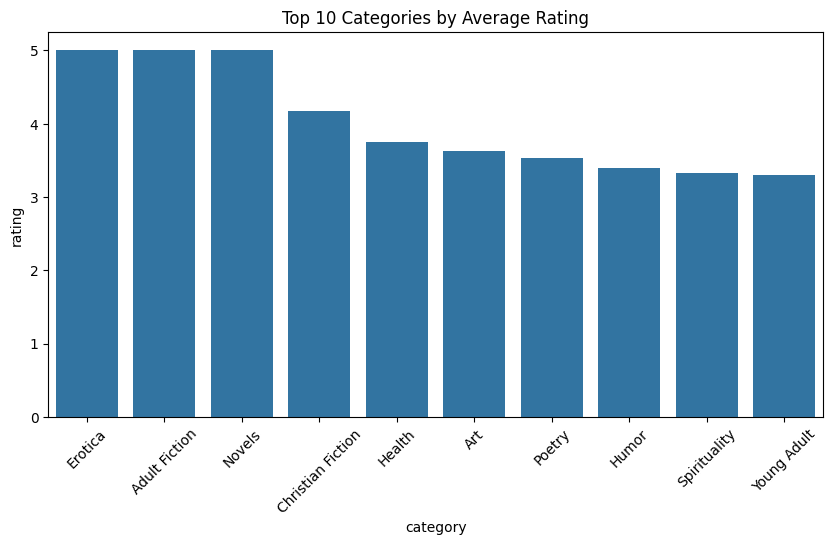

In [113]:
plt.figure(figsize=(10,5))

sns.barplot(data=category_rating,
            x="category",
            y="rating")

plt.xticks(rotation=45)
plt.title("Top 10 Categories by Average Rating")

plt.show()

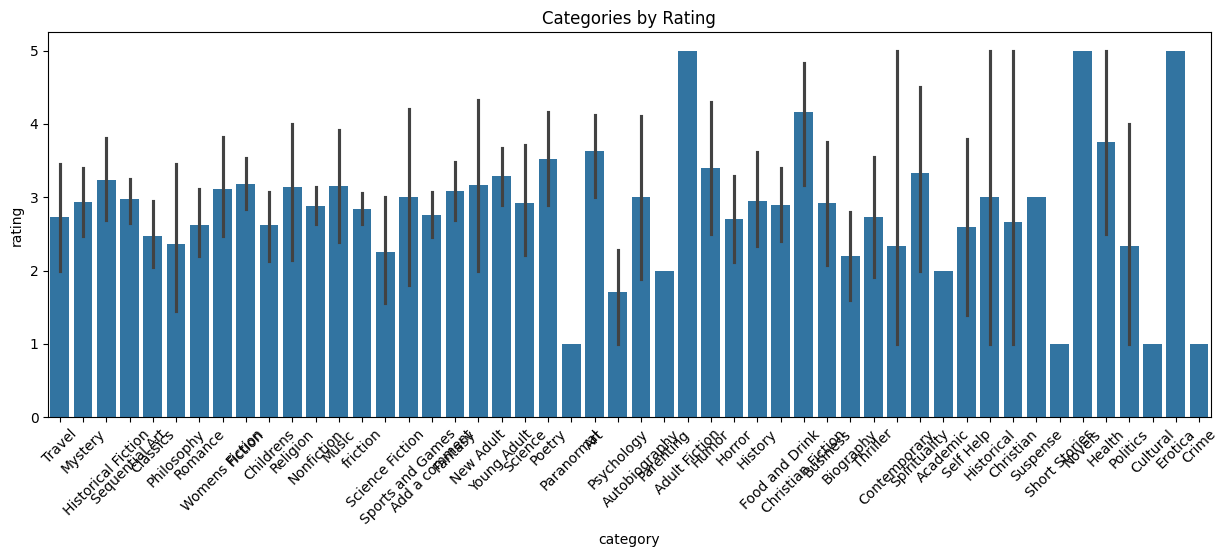

In [114]:
plt.figure(figsize=(15,5))
sns.barplot(data=df,
            x="category",
            y="rating")

plt.xticks(rotation=45)
plt.title("Categories by Rating")

plt.show()

In [115]:
# df["price"] = df["price"].str.replace("£","").str.replace("Â","")
# df["price"] = df["price"].astype(float)
df
# df.drop(columns=["Price"], inplace=True)

,title,price,rating,category
0,It's Only the Himalayas,45.17,2,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,49.43,4,Travel
2,See America: A Celebration of Our National Par...,48.87,3,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,Travel
4,Under the Tuscan Sun,37.33,3,Travel
...,...,...,...,...
995,Why the Right Went Wrong: Conservatism--From G...,52.65,4,Politics
996,Equal Is Unfair: America's Misguided Fight Aga...,56.86,1,Politics
997,Amid the Chaos,36.58,1,Cultural
998,Dark Notes,19.19,5,Erotica


In [116]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "vikas9140"
host = "localhost"
port = "3306"
database = "books_db"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "books"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM books LIMIT 5;", engine)

,title,price,rating,category
0,It's Only the Himalayas,45.17,2,Travel
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,49.43,4,Travel
2,See America: A Celebration of Our National Par...,48.87,3,Travel
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,Travel
4,Under the Tuscan Sun,37.33,3,Travel
